pip install transformers torch
pip install m3inference
pip install seaborn 

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
#from transformers import pipeline เนื่องจากใช้เวลานานจึงยกเลิกไปก่อน
import seaborn as sns

In [3]:
with open("anime_comments_all.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
analyzer = SentimentIntensityAnalyzer()

In [4]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    return score["compound"]

display(df.head(5))

,ID,malID,anime_name,user_c,comment,Genres,season
0,1,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Tkit,This is genuinely the most pathetic new mainst...,"Action, Adventure, Fantasy",winter
1,2,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Marinate1016,No amount of memes or social media posts could...,"Action, Adventure, Fantasy",winter
2,3,58567,Ore dake Level Up na Ken Season 2: Arise from ...,keirashii,This review contains spoilers. If we were to f...,"Action, Adventure, Fantasy",winter
3,4,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Bardwyne,"Just as the last season, Solo Leveling s2 has ...","Action, Adventure, Fantasy",winter
4,5,58567,Ore dake Level Up na Ken Season 2: Arise from ...,ShishiKami,It's honestly just as bad as the previous seas...,"Action, Adventure, Fantasy",winter


In [ ]:

df["sentiment_score"] = df["comment"].apply(get_sentiment)
display(df.head(5))

,ID,malID,anime_name,user_c,comment,Genres,season,sentiment_score
0,1,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Tkit,This is genuinely the most pathetic new mainst...,"Action, Adventure, Fantasy",winter,-0.8229
1,2,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Marinate1016,No amount of memes or social media posts could...,"Action, Adventure, Fantasy",winter,0.9986
2,3,58567,Ore dake Level Up na Ken Season 2: Arise from ...,keirashii,This review contains spoilers. If we were to f...,"Action, Adventure, Fantasy",winter,-0.9999
3,4,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Bardwyne,"Just as the last season, Solo Leveling s2 has ...","Action, Adventure, Fantasy",winter,0.8611
4,5,58567,Ore dake Level Up na Ken Season 2: Arise from ...,ShishiKami,It's honestly just as bad as the previous seas...,"Action, Adventure, Fantasy",winter,-0.8620


In [6]:

df["rating"] = (df["sentiment_score"] + 1) * 5
display(df.head(5))

,ID,malID,anime_name,user_c,comment,Genres,season,sentiment_score,rating
0,1,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Tkit,This is genuinely the most pathetic new mainst...,"Action, Adventure, Fantasy",winter,-0.8229,0.8855
1,2,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Marinate1016,No amount of memes or social media posts could...,"Action, Adventure, Fantasy",winter,0.9986,9.9930
2,3,58567,Ore dake Level Up na Ken Season 2: Arise from ...,keirashii,This review contains spoilers. If we were to f...,"Action, Adventure, Fantasy",winter,-0.9999,0.0005
3,4,58567,Ore dake Level Up na Ken Season 2: Arise from ...,Bardwyne,"Just as the last season, Solo Leveling s2 has ...","Action, Adventure, Fantasy",winter,0.8611,9.3055
4,5,58567,Ore dake Level Up na Ken Season 2: Arise from ...,ShishiKami,It's honestly just as bad as the previous seas...,"Action, Adventure, Fantasy",winter,-0.8620,0.6900


In [7]:

df["Genres"] = df["Genres"].str.split(",")

df = df.explode("Genres")

df["Genres"] = df["Genres"].str.strip()



In [ ]:


# # เช็คว่า Colab เห็น GPU ไหม
# device = 0 if torch.cuda.is_available() else -1

# # โหลดโมเดล Gender
# gender_clf = pipeline(
#     "text-classification",
#     model="padmajabfrl/Gender-Classification",
#     device=device
# )

# # โหลดโมเดล Age (zero-shot)
# age_clf = pipeline(
#     "zero-shot-classification",
#     model="facebook/bart-large-mnli",
#     device=device
# )

# AGE_LABELS = [
#     "13-18 (Teen)",
#     "19-24 (Young Adult)",
#     "25-45 (Adult)"
# ]


# def analyze_demographics_fast(df):

#     # --- Step 1: Group ข้อมูลเหมือนเดิม ---
#     user_texts_df = df.groupby('user_c')['comment'].apply(
#         lambda x: ' '.join(str(i) for i in x)
#     ).reset_index()

#     # ดึง list ของคอมเมนต์ออกมา
#     all_texts = user_texts_df['comment'].str.slice(0, 512).tolist()
#     all_users = user_texts_df['user_c'].tolist()

#     print(f"Start Batch Analysis for {len(all_users)} users...")

#     # --- Step 2: Gender prediction ---
#     gender_predictions = gender_clf(
#         all_texts,
#         batch_size=32,
#         truncation=True
#     )

#     # --- Step 3: Age prediction ---
#     age_predictions = age_clf(
#         all_texts,
#         candidate_labels=AGE_LABELS,
#         batch_size=8
#     )

#     # --- Step 4: เก็บผลลัพธ์ ---
#     gender_results = {}
#     age_results = {}

#     for user, g_pred, a_pred in zip(all_users, gender_predictions, age_predictions):

#         # gender
#         g_label = g_pred['label']
#         gender_results[user] = (
#             "Male" if "Male" in g_label or "LABEL_1" in g_label else "Female"
#         )

#         # age (เลือก label ที่ score สูงสุด)
#         age_results[user] = a_pred['labels'][0]

#     # --- Step 5: Map กลับเข้า df ---
#     df['pred_gender'] = df['user_c'].map(gender_results)
#     df['pred_age_group'] = df['user_c'].map(age_results)

#     return df


# # เรียกใช้งาน
# df = analyze_demographics_fast(df)

# # ตรวจสอบผลลัพธ์
# print("Analysis Completed!")
# print(df[['user_c', 'comment', 'pred_gender', 'pred_age_group']].head(10))

In [8]:
with open("anime_demographics_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

In [9]:
display(df.sample(5))

,ID,malID,anime_name,user_c,comment,Genres,season,sentiment_score,rating,pred_gender,pred_age_group
108049,64941,63054,ex-otogibanashi,@clerithlover4607,bro can you make amv for this movie with anoth...,Fantasy,fall,0.0000,5.0000,Female,13-18 (Teen)
116201,72975,54028,Turkey!,Sylvia,this premise can be good but i fear they re st...,Sports,summer,0.1280,5.6400,Female,25-45 (Adult)
62020,35157,62060,fudanshi shoukan: isekai de shinjuu ni hamerar...,@GMAXPLAYZ,not mushoku tensei though,Boys Love,spring,0.0000,5.0000,Female,13-18 (Teen)
125891,77609,60083,Kowloon Generic Romance,tbhdrinkwater,A great opening episode already love the pair ...,Romance,spring,0.9559,9.7795,Male,25-45 (Adult)
59197,32941,61420,taigu zhan hun,@queendeena,wow is this the new beginnings this is crazy t...,Action,spring,0.3400,6.7000,Male,25-45 (Adult)


# กราฟเรทติ้่งทั้งหมด


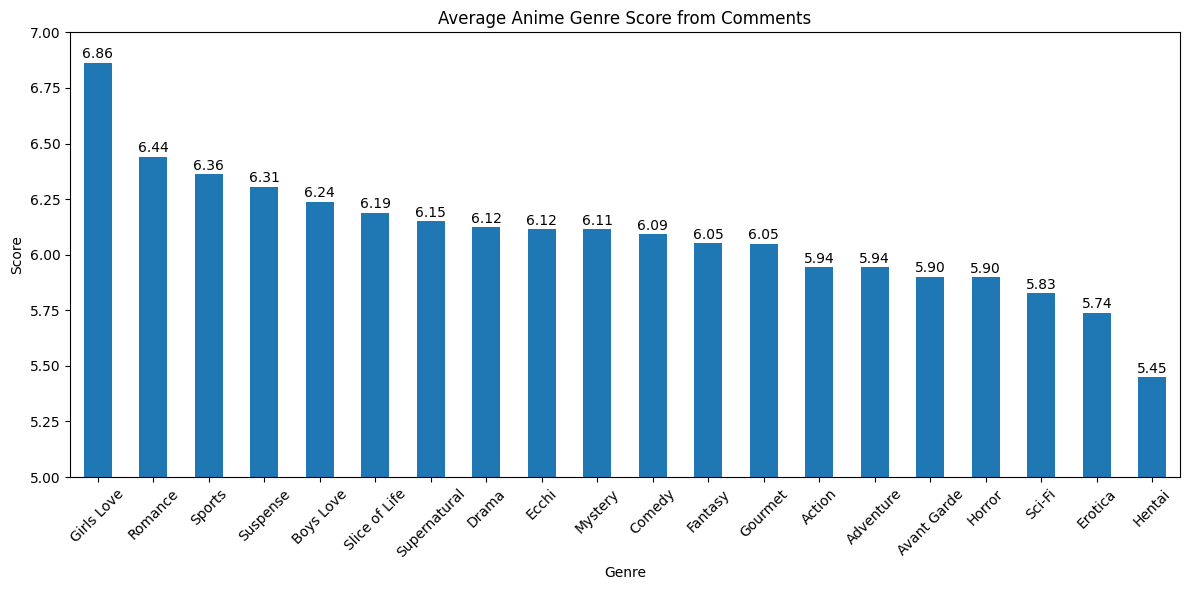

In [10]:

genre_scores = df.groupby("Genres")["rating"].mean().sort_values(ascending=False)


plt.figure(figsize=(12,6))

genre_scores.plot(kind="bar")

plt.title("Average Anime Genre Score from Comments")
plt.xlabel("Genre")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.ylim(5,7)

for i, v in enumerate(genre_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()

plt.show()

# กราฟระหว่างความนิยมกับช่วงอายุ


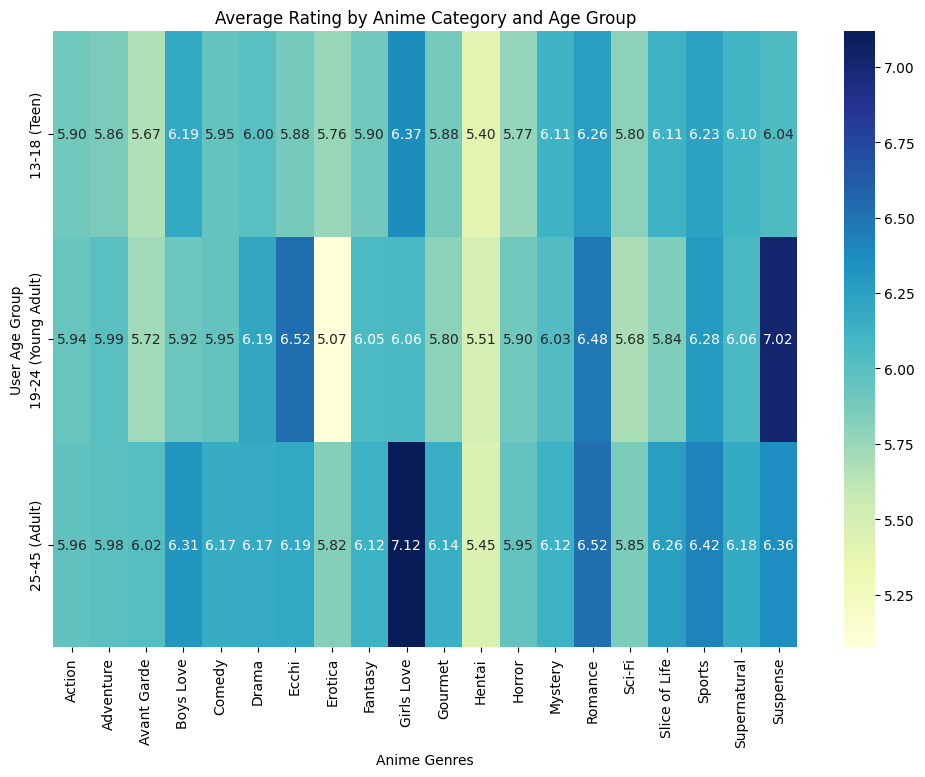

In [ ]:
pivot_table = df.pivot_table(index='pred_age_group', 
                             columns='Genres', 
                             values='rating', 
                             aggfunc='mean')


plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.2f')

plt.title('Average Rating by Anime Category and Age Group')
plt.xlabel('Anime Genres')
plt.ylabel('User Age Group')
plt.show()

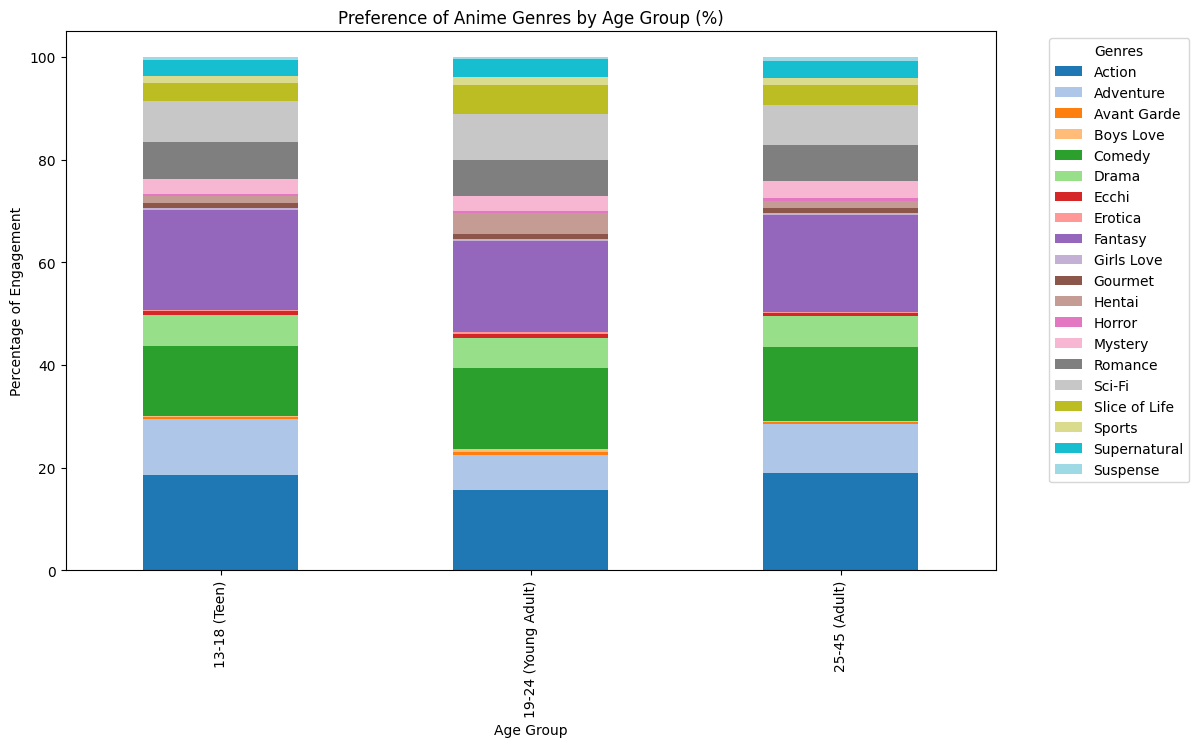

In [5]:

age_cat_counts = pd.crosstab(df['pred_age_group'], df['Genres'], normalize='index') * 100

age_cat_counts.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')
plt.title('Preference of Anime Genres by Age Group (%)')
plt.ylabel('Percentage of Engagement')
plt.xlabel('Age Group')
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

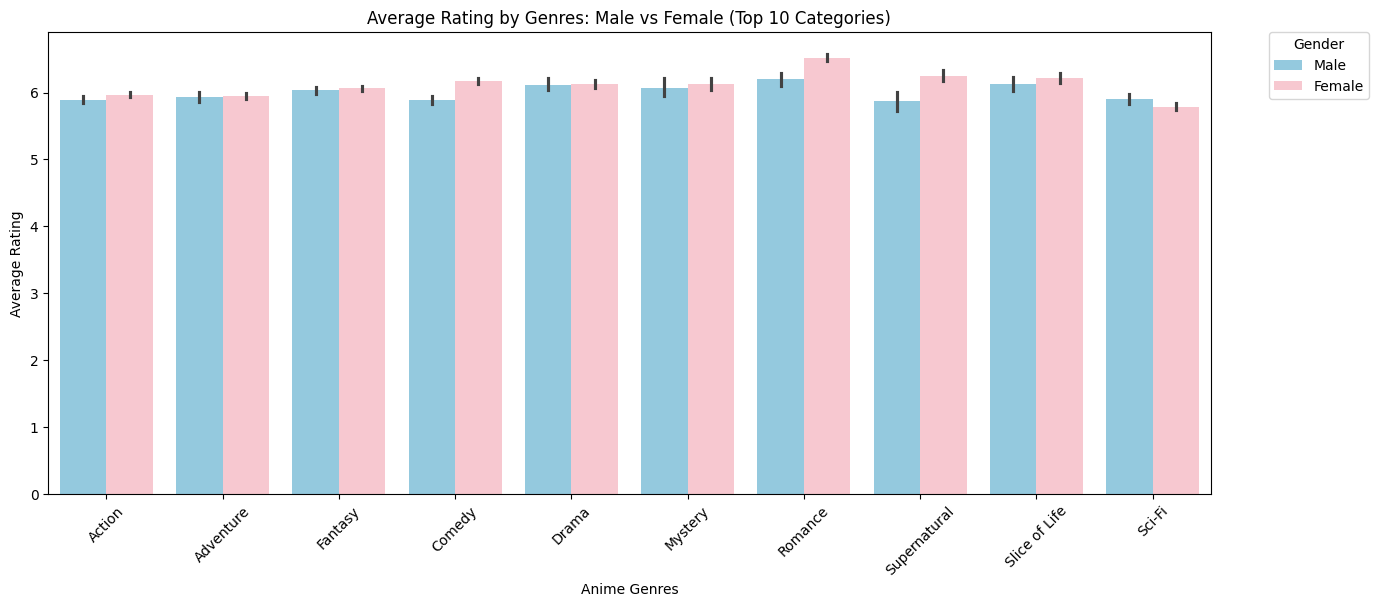

In [ ]:
top_categories = df['Genres'].value_counts().nlargest(10).index
df_top = df[df['Genres'].isin(top_categories)]

plt.figure(figsize=(15, 6))
sns.barplot(data=df_top, x='Genres', y='rating', hue='pred_gender', palette=['skyblue', 'pink'])

plt.title('Average Rating by Genres: Male vs Female (Top 10 Categories)')
plt.ylabel('Average Rating')
plt.xlabel('Anime Genres')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xticks(rotation=45)
plt.show()

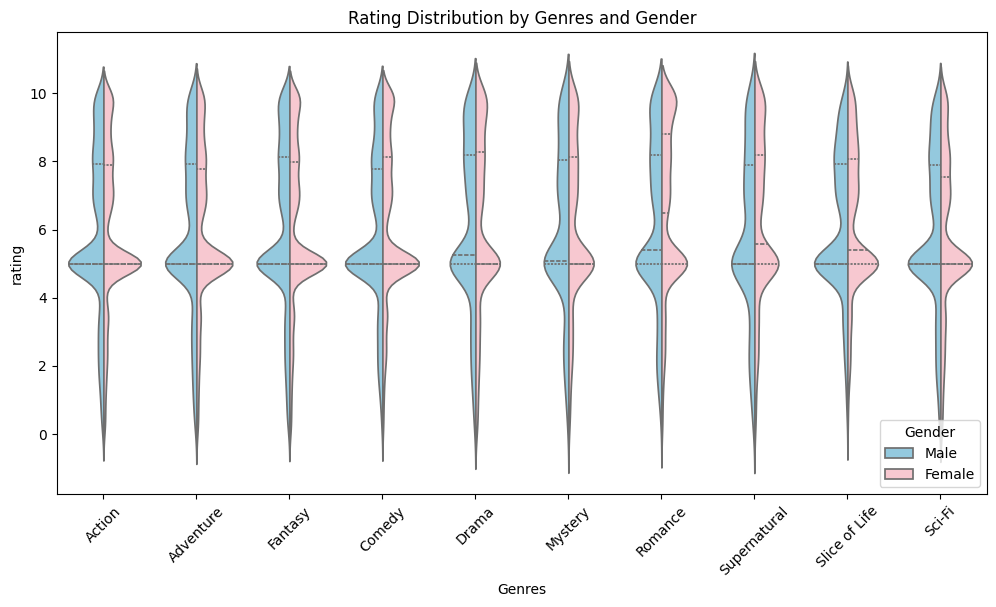

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_top, x='Genres', y='rating', hue='pred_gender', 
               split=True, inner="quart", palette=['skyblue', 'pink'])
plt.legend(title='Gender',loc='lower right')
plt.title('Rating Distribution by Genres and Gender')
plt.xticks(rotation=45)
plt.show()

In [ ]:
anime_scores = df.groupby("anime_name")["rating"].mean().sort_values(ascending=False)

print("\nAverage Anime Scores:")



Average Anime Scores:


กราฟสำหรับ ภาพรวม

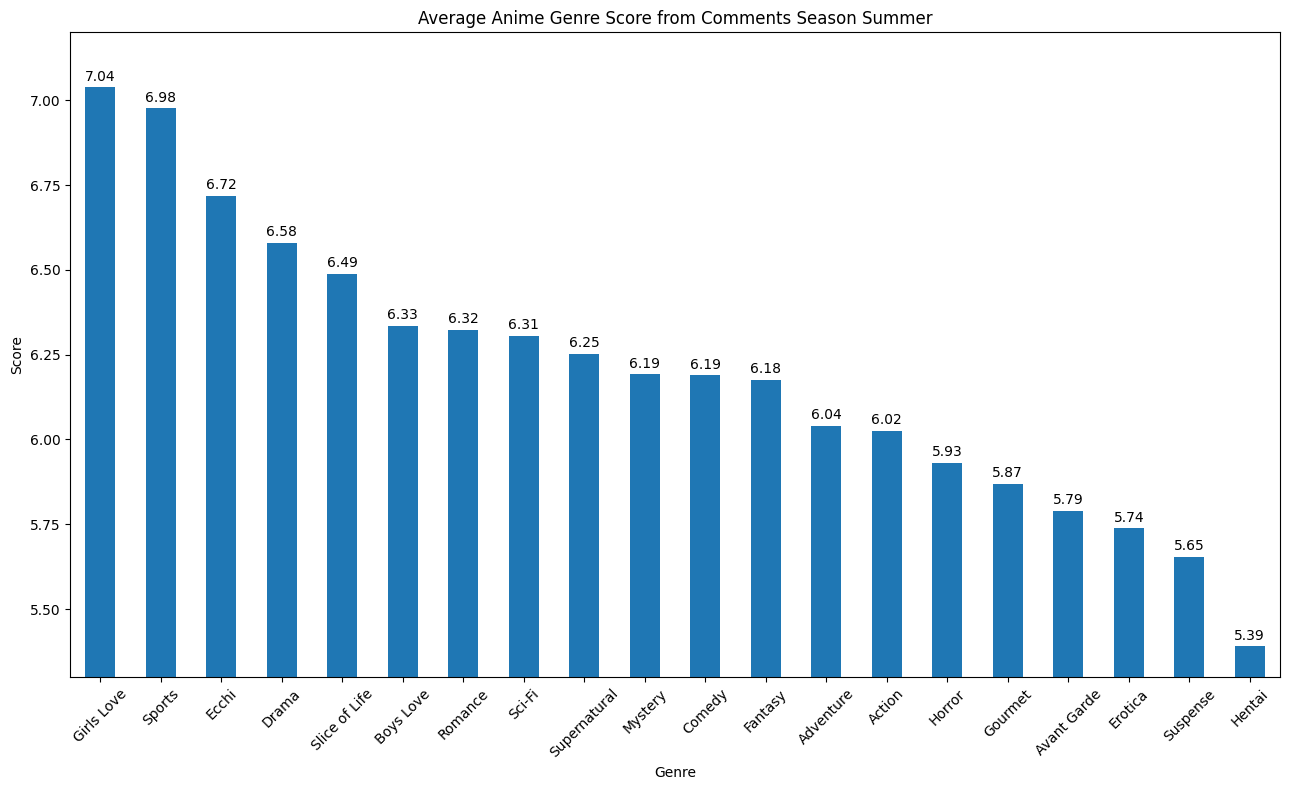

In [ ]:

summer_genre_scores = df.loc[df['season']=="summer"].groupby("Genres")["rating"].mean().sort_values(ascending=False)


plt.figure(figsize=(13,8))

summer_genre_scores.plot(kind="bar")

plt.title("Average Anime Genre Score from Comments Season Summer")
plt.xlabel("Genre")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.ylim(5.3, 7.2) 

for i, v in enumerate(summer_genre_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

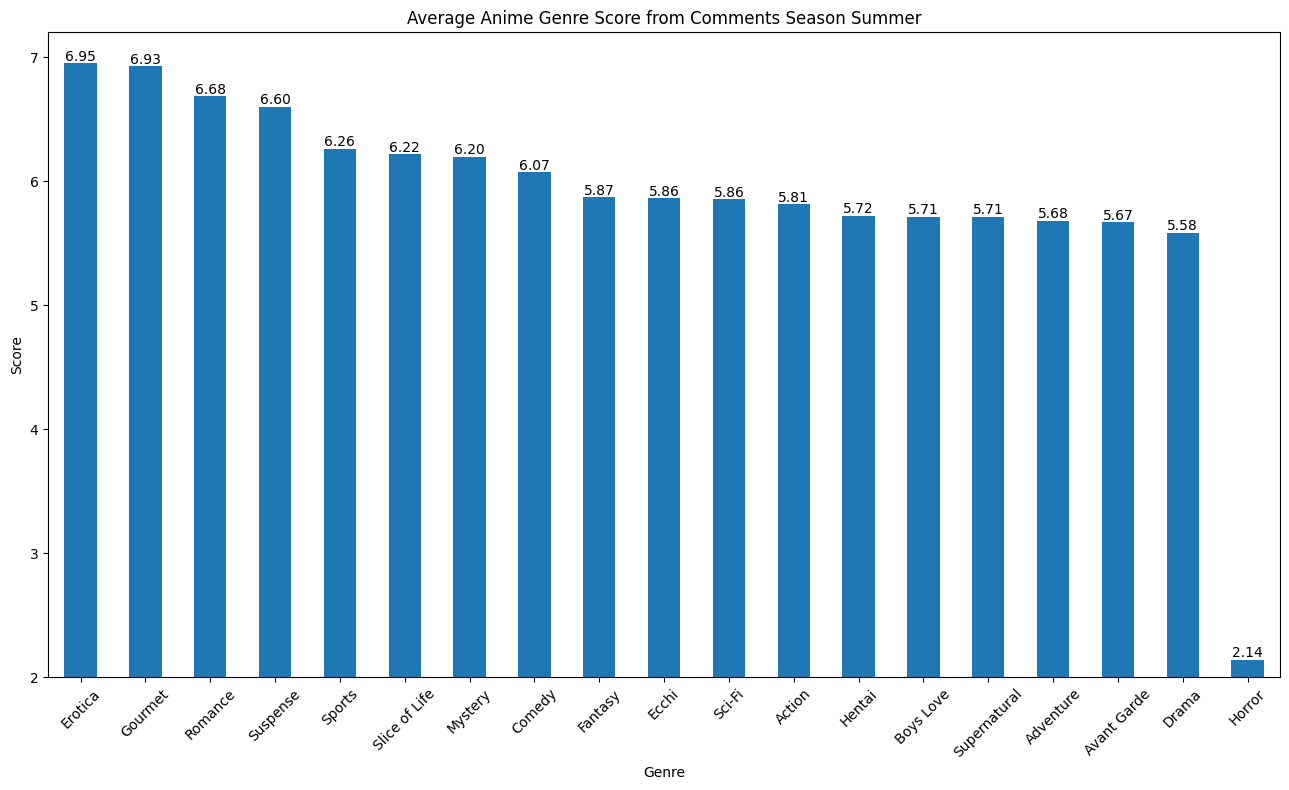

In [ ]:
spring_genre_scores = df.loc[df['season']=="spring"].groupby("Genres")["rating"].mean().sort_values(ascending=False)


plt.figure(figsize=(13,8))

spring_genre_scores.plot(kind="bar")

plt.title("Average Anime Genre Score from Comments Season Spring")
plt.xlabel("Genre")
plt.ylabel("Score")
plt.xticks(rotation=45)


plt.ylim(2, 7.2) 

for i, v in enumerate(spring_genre_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

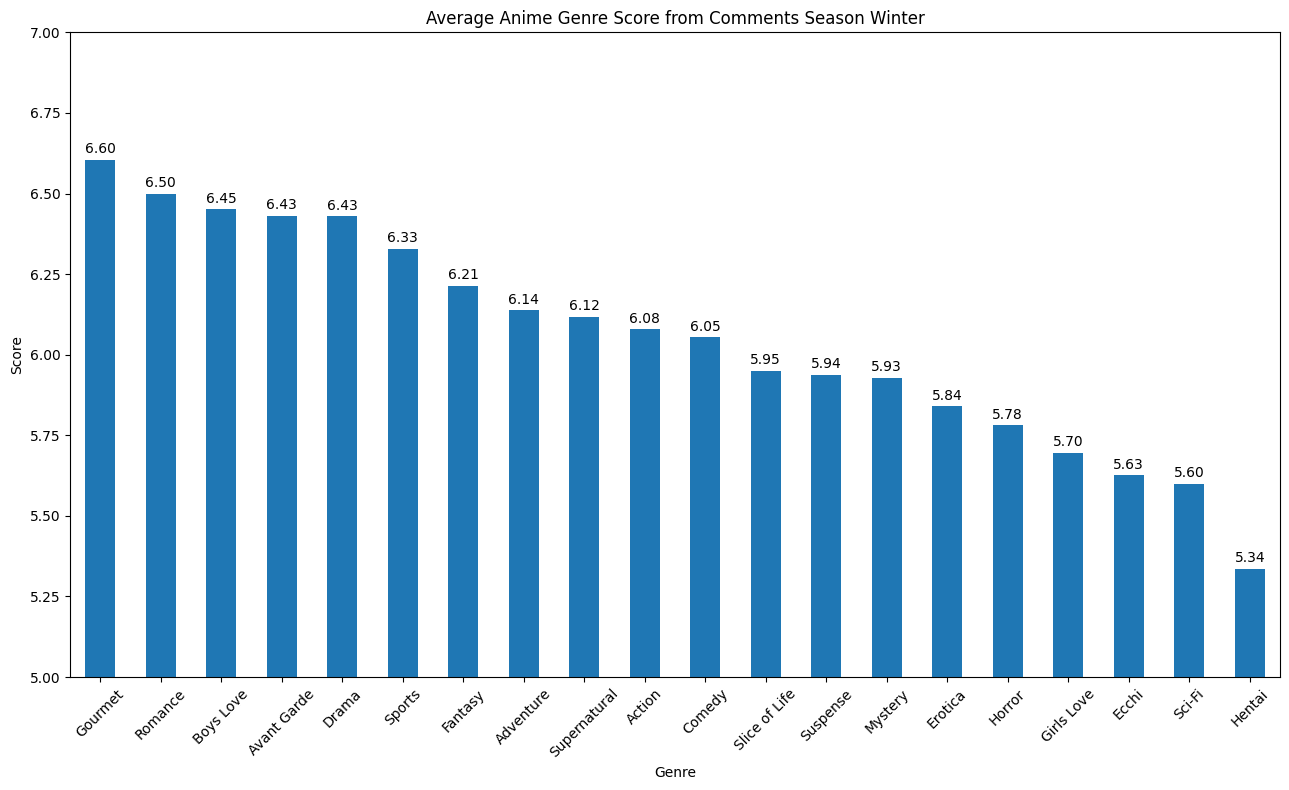

In [ ]:
winter_genre_scores = df.loc[df['season']=="winter"].groupby("Genres")["rating"].mean().sort_values(ascending=False)


plt.figure(figsize=(13,8))


winter_genre_scores.plot(kind="bar")

plt.title("Average Anime Genre Score from Comments Season Winter")
plt.xlabel("Genre")
plt.ylabel("Score")
plt.xticks(rotation=45)


plt.ylim(5,7)

for i, v in enumerate(winter_genre_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

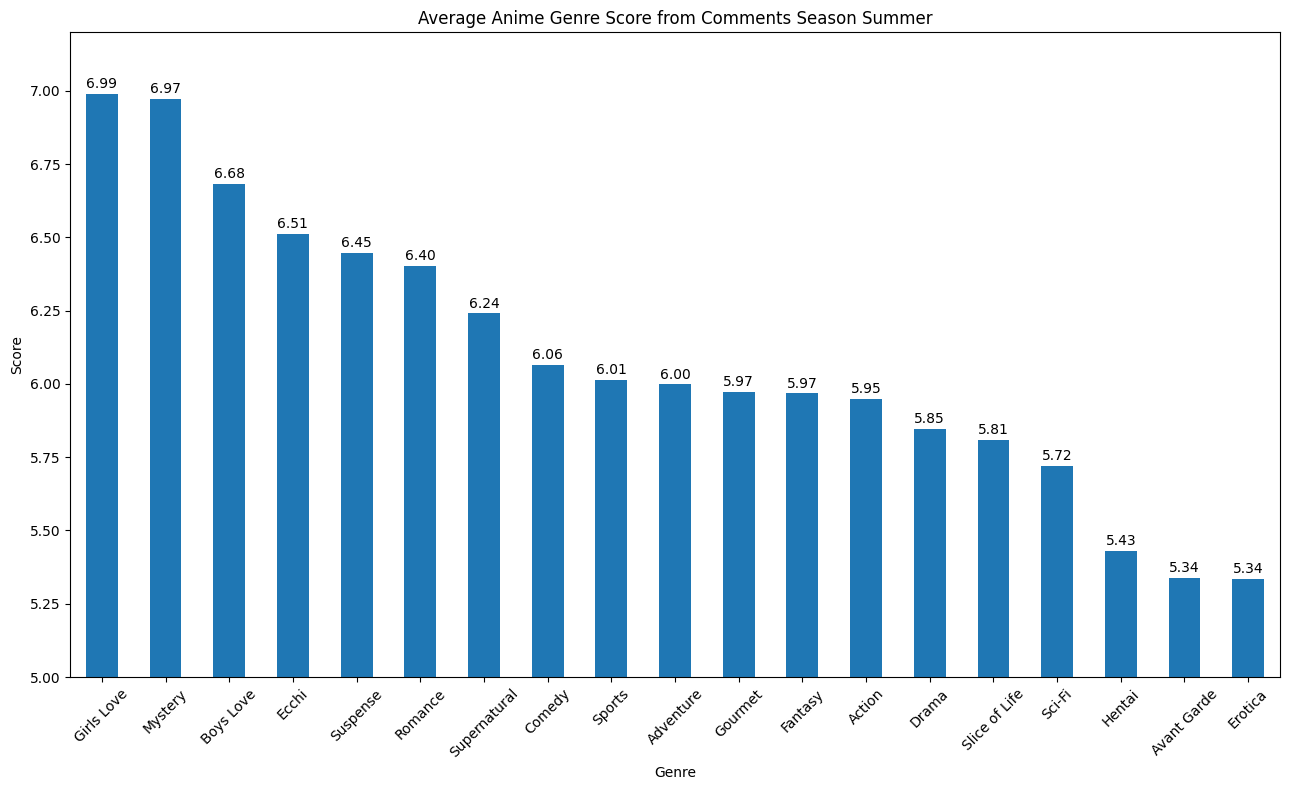

In [ ]:
fall_genre_scores = df.loc[df['season']=="fall"].groupby("Genres")["rating"].mean().sort_values(ascending=False)


plt.figure(figsize=(13,8))

fall_genre_scores.plot(kind="bar")

plt.title("Average Anime Genre Score from Comments Season Summer")
plt.xlabel("Genre")
plt.ylabel("Score")
plt.xticks(rotation=45)


plt.ylim(5, 7.2) 

for i, v in enumerate(fall_genre_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()